# Расчет параметров эффективности математической модели

In [13]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as gamma_dist

from exceptions import MathModelException
from config import MathModelInput, load_config
import executor
import replicaset
import user

from render_typst import FormulaRenderer, get_typst_context

TYPST_PATH: Path = Path("../diploma/math-stuff.typ")
TYPST_RENDERER: FormulaRenderer = FormulaRenderer()
TYPST_CONTEXT: str = get_typst_context(TYPST_PATH)


def output(t: str):
    TYPST_RENDERER.render(TYPST_CONTEXT + t)

Здесь задается конфиг, по которому будут рассчитаны параметры эффективности

In [14]:
CONFIG_PATH = "configs/example.yaml"

In [15]:
MATH_MODEL_INPUT: MathModelInput = load_config(CONFIG_PATH)

print(f"Загруженные настройки: {MATH_MODEL_INPUT}")

Загруженные настройки: intensity_search_LSI=200000.0 intensity_update_LSI=100000.0 intensity_search_GSI=200000.0 intensity_update_GSI=100000.0 replicaset_count=15 cluster_time_k=1.5 cluster_time_theta=0.02 cluster_net_speed=100000000.0 user_time_k=2.0 user_time_theta=0.2 user_net_speed=1000000.0 row_size=128 data_cardinality=1000 fk_cardinality=100 cpu_frequency=4000000000.0 mem_frequency=10000000.0 wal_time=0.002 timeout=2.0 btree_order=4096


Добавим алиасы для удоства и вычислим общие величины

In [16]:
replicaset_count = MATH_MODEL_INPUT.replicaset_count

cluster_time_theta, cluster_time_k = (
    MATH_MODEL_INPUT.cluster_time_theta,
    MATH_MODEL_INPUT.cluster_time_k,
)
user_time_theta, user_time_k = (
    MATH_MODEL_INPUT.user_time_theta,
    MATH_MODEL_INPUT.user_time_k,
)

data_cardinality_per_replicaset = replicaset.data_cardinality_per_replicaset(
    MATH_MODEL_INPUT.data_cardinality, MATH_MODEL_INPUT.replicaset_count
)
pk_per_fk_cardinality_per_replicaset = replicaset.pk_per_fk_cardinality_per_replicaset(
    data_cardinality_per_replicaset, MATH_MODEL_INPUT.fk_cardinality
)

pk_per_fk_cardinality = pk_per_fk_cardinality_per_replicaset * replicaset_count

### Поиск в ЛВИ

Вычислим время работы исполнителя

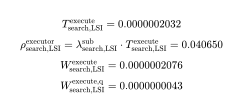

In [17]:
time_execute_search_LSI = executor.time_execute_search_LSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

subintensity_search_LSI = MATH_MODEL_INPUT.intensity_search_LSI
load_executor_search_LSI = executor.load(
    subintensity_search_LSI, time_execute_search_LSI
)

if load_executor_search_LSI > 1:
    raise MathModelException(
        f"Исполнитель не справляется с нагрузкой! загрузка системы равна {load_executor_search_LSI:.3f}"
    )

queue_length_execute_search_LSI = (
    executor.pollaczek_khinchin_deterministic_queue_length(
        subintensity_search_LSI, time_execute_search_LSI
    )
)
service_time_execute_search_LSI = executor.littles_law_deterministic(
    queue_length_execute_search_LSI, subintensity_search_LSI
)
queue_time_execute_search_LSI = executor.queue_time_deterministic(
    service_time_execute_search_LSI, time_execute_search_LSI
)

output(rf"""
$#time_execute_search_LSI = "{time_execute_search_LSI:.10f}"$

$#load_executor_search_LSI = #subintensity_search_LSI dot #time_execute_search_LSI = {load_executor_search_LSI:5f}$

$#service_time_execute_search_LSI = {service_time_execute_search_LSI:.10f}$

$#queue_time_execute_search_LSI = {queue_time_execute_search_LSI:.10f}$
""")

Рассчитаем время ожидания пользователем

In [18]:
exec_plan_size_search_LSI = replicaset.exec_plan_size(MATH_MODEL_INPUT.row_size)
query_size_search_LSI = replicaset.query_size(MATH_MODEL_INPUT.row_size)

# детерминированная часть задержки работы исполнителя
deterministic_part_of_tcsi_search_LSI = (
    exec_plan_size_search_LSI
    + MATH_MODEL_INPUT.row_size * pk_per_fk_cardinality_per_replicaset
) / MATH_MODEL_INPUT.cluster_net_speed

# детерминированная часть задержки ожидания пользователя
deterministic_part_of_tus_search_LSI = (
    query_size_search_LSI
    + MATH_MODEL_INPUT.row_size
    * pk_per_fk_cardinality_per_replicaset
    * MATH_MODEL_INPUT.replicaset_count
) / MATH_MODEL_INPUT.user_net_speed + deterministic_part_of_tcsi_search_LSI


# сетка для расчета случайных величин
dx_search_LSI = 0.0002
x_grid_search_LSI = np.arange(0.0, 30.0 + dx_search_LSI, dx_search_LSI)

# задержка пользователь-координатор запрос-ответ
time_user_request_response_LSI_pdf = gamma_dist.pdf(
    x_grid_search_LSI, a=user_time_k, scale=user_time_theta
)

# задержка координатор-исполнитель запрос-ответ
time_cluster_request_response_coordinator_executor_i_LSI_pdf = gamma_dist.pdf(
    x_grid_search_LSI,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
time_cluster_request_response_coordinator_executor_i_LSI_cdf = gamma_dist.cdf(
    x_grid_search_LSI,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
# макс. задержка координатор-исполнитель запрос-ответ
time_cluster_request_response_coordinator_executor_LSI_pdf = (
    MATH_MODEL_INPUT.replicaset_count
    * time_cluster_request_response_coordinator_executor_i_LSI_cdf
    ** (MATH_MODEL_INPUT.replicaset_count - 1)
    * time_cluster_request_response_coordinator_executor_i_LSI_pdf
)

# светрка задержки пользователь-координатор и координатор-исполнитель запрос-ответ
time_user_request_response_pdf = (
    np.convolve(
        time_user_request_response_LSI_pdf,
        time_cluster_request_response_coordinator_executor_LSI_pdf,
    )
    * dx_search_LSI
)
# сдвинутая сетка, т.к. добавляем константу
time_user_request_response_grid = np.arange(
    0.0, 2 * x_grid_search_LSI[-1] + dx_search_LSI, dx_search_LSI
)[: len(time_user_request_response_pdf)]
time_request_response_grid_offset = (
    time_user_request_response_grid + deterministic_part_of_tus_search_LSI
)

# проверим, что интеграл плотности равен единице
time_request_response_pdf_integral = np.trapezoid(
    time_user_request_response_pdf, time_request_response_grid_offset
)
print(f"Интеграл плотности СВ = {time_request_response_pdf_integral:.6f}")

# мат. ожидание и дисперсия общения пользователь-координатор
time_user_request_response_mean, time_user_request_response_variance = (
    user_time_k * user_time_theta,
    user_time_k * user_time_theta**2,
)
# мат. ожидание и дисперсия общения максимума координатор-исполнитель
time_cluster_request_response_max_mean: float = np.trapezoid(
    x_grid_search_LSI * time_cluster_request_response_coordinator_executor_LSI_pdf,
    x_grid_search_LSI,
)  # type: ignore
time_cluster_request_response_max_moment_2: float = np.trapezoid(
    x_grid_search_LSI**2 * time_cluster_request_response_coordinator_executor_LSI_pdf,
    x_grid_search_LSI,
)  # type: ignore
time_cluster_request_response_max_variance = (
    time_cluster_request_response_max_moment_2
    - time_cluster_request_response_max_mean**2
)
# общие мат. ожидание и дисперсия
time_user_search_LSI_mean = (
    time_user_request_response_mean
    + time_cluster_request_response_max_mean
    + deterministic_part_of_tus_search_LSI
)
time_user_search_LSI_variance = (
    time_user_request_response_variance + time_cluster_request_response_max_variance
)
time_user_search_LSI_std_deviance = np.sqrt(time_user_search_LSI_variance)

print(f"M[Z]: {time_user_search_LSI_mean:.6f}")
print(f"D[Z]: {time_user_search_LSI_variance:.6f}")

Интеграл плотности СВ = 1.000000
M[Z]: 0.572097
D[Z]: 0.083056


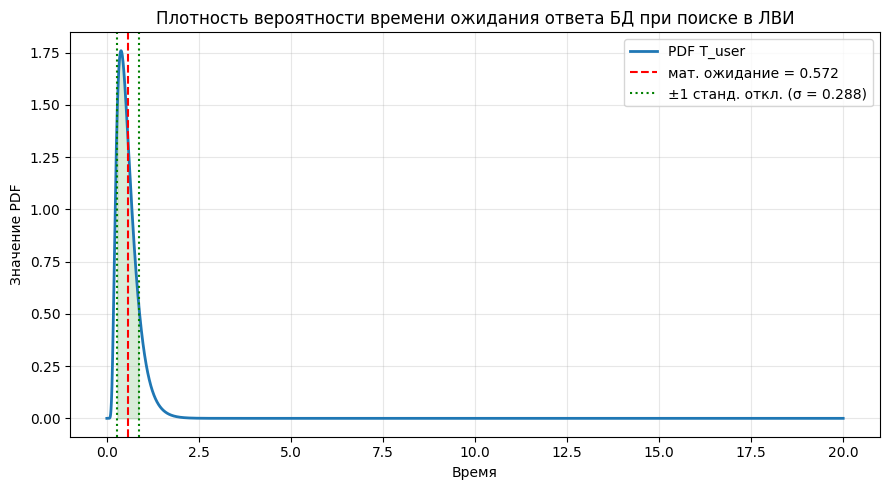

In [19]:
plt.figure(figsize=(9, 5))
time_user_search_LSI_plot_interval = (time_user_request_response_grid >= 0) & (
    time_user_request_response_grid <= 20
)
plt.plot(
    time_user_request_response_grid[time_user_search_LSI_plot_interval],
    time_user_request_response_pdf[time_user_search_LSI_plot_interval],
    label="PDF T_user",
    lw=2,
)
plt.axvline(
    time_user_search_LSI_mean,
    color="r",
    ls="--",
    label=f"мат. ожидание = {time_user_search_LSI_mean:.3f}",
)
plt.axvline(
    time_user_search_LSI_mean - time_user_search_LSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1 станд. откл. (σ = {time_user_search_LSI_std_deviance:.3f})",
)
plt.axvline(
    time_user_search_LSI_mean + time_user_search_LSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
)
plt.fill_between(
    time_user_request_response_grid,
    time_user_request_response_pdf,
    where=(
        (
            time_user_request_response_grid
            >= time_user_search_LSI_mean - time_user_search_LSI_std_deviance
        )
        & (
            time_user_request_response_grid
            <= time_user_search_LSI_mean + time_user_search_LSI_std_deviance
        )
    ),
    color="green",
    alpha=0.15,
)
plt.title("Плотность вероятности времени ожидания ответа БД при поиске в ЛВИ")
plt.xlabel("Время")
plt.ylabel("Значение PDF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Показатели эффективности

Максимальная нагрузка на систему, среднее время обслуживания заявки, среднее время ожидания заявки в очереди и вероятность необслуживания заявки

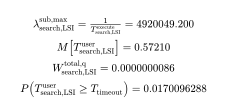

In [20]:
max_load_executor_search_LSI = 1 / time_execute_search_LSI
prob_timeout_search_LSI = user.prob_timeout_search_LSI(
    MATH_MODEL_INPUT.timeout,
    user_time_k,
    user_time_theta,
    cluster_time_k,
    cluster_time_theta,
    queue_time_execute_search_LSI,
    deterministic_part_of_tcsi_search_LSI,
    query_size_search_LSI,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.replicaset_count,
    MATH_MODEL_INPUT.row_size,
    MATH_MODEL_INPUT.user_net_speed,
)

output(rf"""
$#max_subintensity_search_LSI = 1 / #time_execute_search_LSI = {max_load_executor_search_LSI:.3f}$

$M[#time_user_search_LSI] = {time_user_search_LSI_mean:.5f}$

$#queue_time_total_search_LSI = {2 * queue_time_execute_search_LSI:.10f}$

$P(#time_user_search_LSI >= #timeout) = {prob_timeout_search_LSI:.10f}$
""")

## Поиск в ГВИ

Вычислим время работы исполнителей

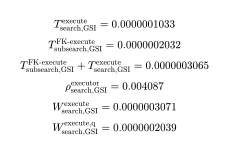

In [21]:
time_execute_search_GSI = executor.time_execute_search_GSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

time_execute_fk_subsearch_GSI = executor.time_execute_fk_subsearch_GSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

replicaset_count_with_fk: float = math.ceil(
    replicaset_count
    / (MATH_MODEL_INPUT.data_cardinality / MATH_MODEL_INPUT.fk_cardinality)
)

subintensity_search_GSI = MATH_MODEL_INPUT.intensity_search_GSI / pk_per_fk_cardinality
load_executor_search_GSI = executor.load(
    subintensity_search_GSI, (time_execute_search_GSI + time_execute_fk_subsearch_GSI)
)

if load_executor_search_GSI > 1:
    raise MathModelException(
        f"Исполнитель не справляется с нагрузкой! загрузка системы равна {load_executor_search_GSI:.3f}"
    )

queue_length_execute_search_GSI = (
    executor.pollaczek_khinchin_deterministic_queue_length(
        subintensity_search_GSI,
        (time_execute_search_GSI + time_execute_fk_subsearch_GSI),
    )
)
service_time_execute_search_GSI = executor.littles_law_deterministic(
    queue_length_execute_search_GSI, subintensity_search_GSI
)
queue_time_execute_search_GSI = executor.queue_time_deterministic(
    service_time_execute_search_GSI, time_execute_search_GSI
)

output(rf"""
$#time_execute_search_GSI = "{time_execute_search_GSI:.10f}"$

$#time_execute_fk_subsearch_GSI = "{time_execute_fk_subsearch_GSI:.10f}"$

$#time_execute_fk_subsearch_GSI + #time_execute_search_GSI = "{time_execute_fk_subsearch_GSI + time_execute_search_GSI:.10f}"$

$#load_executor_search_GSI = {load_executor_search_GSI:5f}$

$#service_time_execute_search_GSI = {service_time_execute_search_GSI:.10f}$

$#queue_time_execute_search_GSI = {queue_time_execute_search_GSI:.10f}$
""")

Рассчитаем время ожидания пользователем

In [22]:
exec_plan_size_search_GSI = replicaset.exec_plan_size(MATH_MODEL_INPUT.row_size)
query_size_search_GSI = replicaset.query_size(MATH_MODEL_INPUT.row_size)

# детерминированная часть задержки работы исполнителя
deterministic_part_of_tfei_GSI = (
    (
        exec_plan_size_search_GSI
        + MATH_MODEL_INPUT.row_size
        * pk_per_fk_cardinality_per_replicaset
        * replicaset_count
    )
    / MATH_MODEL_INPUT.cluster_net_speed
    + queue_time_execute_search_GSI
    + time_execute_search_GSI
)

# детерминированная часть задержки работы исполнителя со вторичными ключами
deterministic_part_of_tfe_GSI = (
    queue_time_execute_search_GSI
    + time_execute_fk_subsearch_GSI
    + deterministic_part_of_tfei_GSI
)

# детерминированная часть задержки работы координатора
deterministic_part_of_tcs_GSI = (
    (exec_plan_size_search_GSI * pk_per_fk_cardinality_per_replicaset)
    / MATH_MODEL_INPUT.cluster_net_speed
    + queue_time_execute_search_GSI
    + deterministic_part_of_tfe_GSI
)

# детерминированная часть задержки ожидания пользователя
deterministic_part_of_tus_GSI = (
    query_size_search_GSI
    + MATH_MODEL_INPUT.row_size
    * pk_per_fk_cardinality_per_replicaset
    * MATH_MODEL_INPUT.replicaset_count
) / MATH_MODEL_INPUT.user_net_speed + deterministic_part_of_tcs_GSI

# сетка для расчета случайных величин
dx_search_GSI = 0.0002
x_grid_search_GSI = np.arange(0.0, 30.0 + dx_search_GSI, dx_search_GSI)

# задержка пользователь-координатор запрос-ответ
time_user_request_response_GSI_pdf = gamma_dist.pdf(
    x_grid_search_GSI, a=user_time_k, scale=user_time_theta
)

# задержка координатор-исполнитель вторичных ключей запрос-ответ
time_cluster_request_response_coordinator_fk_executor_GSI_pdf = gamma_dist.pdf(
    x_grid_search_GSI,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)

# задержка исполнитель вторичных ключей-исполнитель запрос-ответ
time_cluster_request_response_fk_executor_executor_i_GSI_pdf = gamma_dist.pdf(
    x_grid_search_GSI,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
time_cluster_request_response_fk_executor_executor_i_GSI_cdf = gamma_dist.cdf(
    x_grid_search_GSI,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
# макс. задержка исполнитель вторичных ключей-исполнитель запрос-ответ
time_cluster_request_response_fk_executor_executor_max_GSI_pdf = (
    MATH_MODEL_INPUT.replicaset_count
    * time_cluster_request_response_fk_executor_executor_i_GSI_cdf
    ** (MATH_MODEL_INPUT.replicaset_count - 1)
    * time_cluster_request_response_fk_executor_executor_i_GSI_pdf
)

# свертка задержки координатор-исполнитель и координатор-исполнитель вторичных ключей запрос-ответ
time_coordinator_executors_request_response_pdf = (
    np.convolve(
        time_cluster_request_response_coordinator_fk_executor_GSI_pdf,
        time_cluster_request_response_fk_executor_executor_max_GSI_pdf,
    )
    * dx_search_GSI
)

# свертка задержки от пользователя до исполнителей запрос-ответ
time_user_request_response_pdf = (
    np.convolve(
        time_coordinator_executors_request_response_pdf,
        time_user_request_response_GSI_pdf,
    )
    * dx_search_GSI
)

# сдвинутая сетка, т.к. добавляем константу
time_user_request_response_grid = np.arange(
    0.0, 4 * x_grid_search_GSI[-1] + dx_search_GSI, dx_search_GSI
)[: len(time_user_request_response_pdf)]
time_request_response_grid_offset = (
    time_user_request_response_grid + deterministic_part_of_tus_GSI
)

# рассмотрим, где плотность явно ненулевая
time_request_response_grid_mask = time_user_request_response_grid <= 30.0
time_request_response_grid_masked = time_user_request_response_grid[
    time_request_response_grid_mask
]
time_request_response_pdf_masked = time_user_request_response_pdf[
    time_request_response_grid_mask
]

# проверим, что интеграл плотности равен единице
time_request_response_pdf_integral = np.trapezoid(
    time_user_request_response_pdf, time_request_response_grid_offset
)
print(f"Интеграл плотности СВ = {time_request_response_pdf_integral:.6f}")

# моменты случайной части времени ожидания пользователя
time_request_response_pdf_mean: float = np.trapezoid(
    time_request_response_grid_masked * time_request_response_pdf_masked,
    time_request_response_grid_masked,
)  # type: ignore
time_request_response_pdf_moment_2: float = np.trapezoid(
    time_request_response_grid_masked**2 * time_request_response_pdf_masked,
    time_request_response_grid_masked,
)  # type: ignore

# мат. ожидание и дисперсия общения пользователь-кластер
time_user_search_GSI_mean = (
    time_request_response_pdf_mean + deterministic_part_of_tus_GSI
)
time_user_search_GSI_variance = (
    time_request_response_pdf_moment_2 - time_request_response_pdf_mean**2
)
time_user_search_GSI_std_deviance = np.sqrt(time_user_search_GSI_variance)

print(f"M[Z]: {time_user_search_GSI_mean:.6f}")
print(f"D[Z]: {time_user_search_GSI_variance:.6f}")

Интеграл плотности СВ = 0.999917
M[Z]: 0.632071
D[Z]: 0.085481


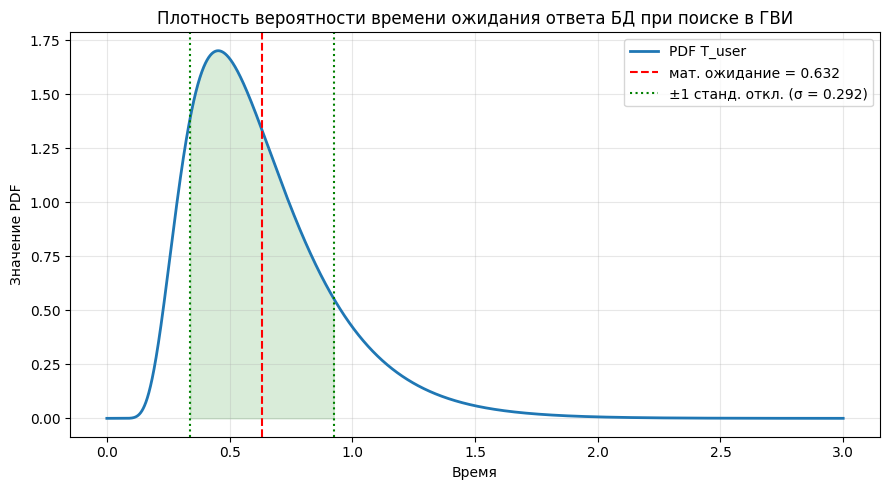

In [23]:
plt.figure(figsize=(9, 5))
time_user_search_GSI_plot_interval = (time_request_response_grid_masked >= 0) & (
    time_request_response_grid_masked <= 3
)
plt.plot(
    time_request_response_grid_masked[time_user_search_GSI_plot_interval],
    time_request_response_pdf_masked[time_user_search_GSI_plot_interval],
    label="PDF T_user",
    lw=2,
)
plt.axvline(
    time_user_search_GSI_mean,
    color="r",
    ls="--",
    label=f"мат. ожидание = {time_user_search_GSI_mean:.3f}",
)
time_user_search_GSI_std_deviance = np.sqrt(time_user_search_GSI_variance)
plt.axvline(
    time_user_search_GSI_mean - time_user_search_GSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1 станд. откл. (σ = {time_user_search_GSI_std_deviance:.3f})",
)
plt.axvline(
    time_user_search_GSI_mean + time_user_search_GSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
)
plt.fill_between(
    time_request_response_grid_masked,
    time_request_response_pdf_masked,
    where=(
        (
            time_request_response_grid_masked
            >= time_user_search_GSI_mean - time_user_search_GSI_std_deviance
        )
        & (
            time_request_response_grid_masked
            <= time_user_search_GSI_mean + time_user_search_GSI_std_deviance
        )
    ),
    color="green",
    alpha=0.15,
)
plt.title("Плотность вероятности времени ожидания ответа БД при поиске в ГВИ")
plt.xlabel("Время")
plt.ylabel("Значение PDF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Показатели эффективности

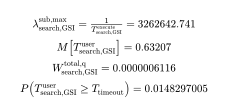

In [24]:
max_load_executor_search_GSI = 1 / (
    time_execute_fk_subsearch_GSI + time_execute_search_GSI
)
prob_timeout_search_GSI = user.prob_timeout_search_GSI(
    MATH_MODEL_INPUT.timeout,
    user_time_k,
    user_time_theta,
    cluster_time_k,
    cluster_time_theta,
    deterministic_part_of_tus_GSI,
    replicaset_count_with_fk,
)

output(rf"""
$#max_subintensity_search_GSI = 1 / #time_execute_search_GSI = {max_load_executor_search_GSI:.3f}$

$M[#time_user_search_GSI] = {time_user_search_GSI_mean:.5f}$

$#queue_time_total_search_GSI = {3 * queue_time_execute_search_GSI:.10f}$

$P(#time_user_search_GSI >= #timeout) = {prob_timeout_search_GSI:.10f}$
""")
